# Customer Churn Prediction - Data Mining Project
**Group Members:**
- MD.Fahad Ali (ID: 221002313)

## Project Overview
This project implements a complete Data Mining process to predict customer churn.
Methodology includes:
1.  **Data Hygiene & Insight** (Preprocessing & EDA)
2.  **Feature Engineering & Selection**
3.  **Visualizing Complexity** (Dimensionality Reduction)
4.  **Customer Profiling** (Clustering)
5.  **Future Prediction** (Classification)
6.  **Model Enhancement** (Ensemble Methods)
7.  **Security & Quality Control** (Anomaly Detection)


In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SciKit-Learn modules
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import RFE

# XGBoost
try:
    import xgboost as xgb
except ImportError:
    %pip install xgboost
    import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Data Loading

In [2]:
# 2. Data Loading
# Using Telco Customer Churn dataset URL directly
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully!")
except Exception as e:
    print(f"Error loading dataset: {e}")
    # Fallback if URL fails, assume local upload
    # df = pd.read_csv('Telco-Customer-Churn.csv')

df.head()

Dataset loaded successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Preprocessing

In [3]:
# 3. Data Hygiene & Insight (Preprocessing)
# Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# 'TotalCharges' is object but should be numeric. Coerce errors to NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Drop customerID as it's not a feature
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Encode Categorical Variables
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("\nData shape after cleaning:", df.shape)
df.head()

Missing values before cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data shape after cleaning: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## 3. Exploratory Data Analysis

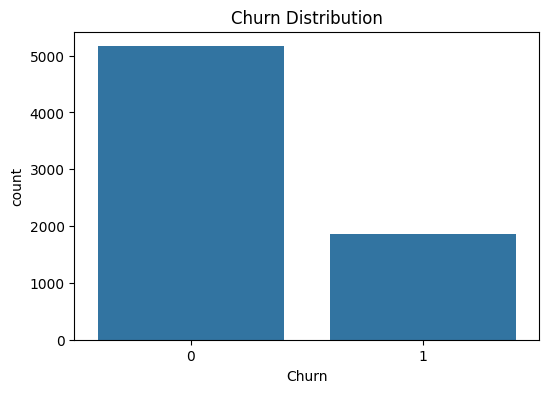

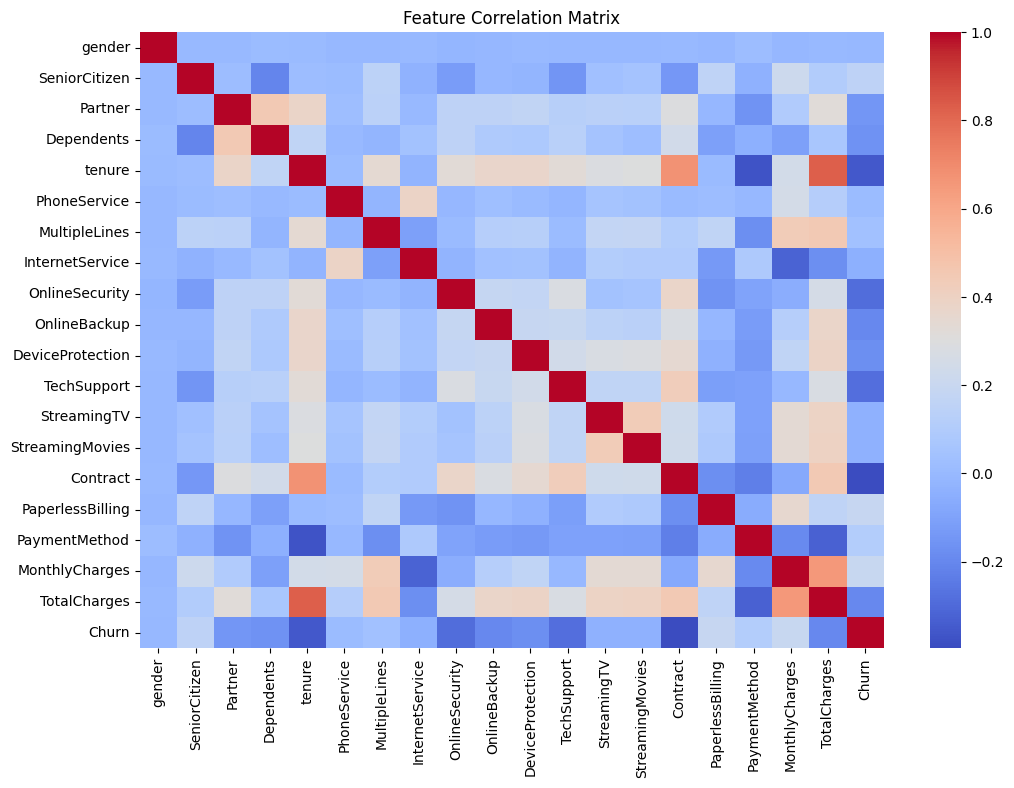

In [4]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

## 4. Feature Engineering

In [5]:
# 4. Feature Engineering & Selection
# Creating new feature: Average Monthly Charge per Tenure unit
# Avoid division by zero
df['AvgChargePerTenure'] = df['TotalCharges'] / (df['tenure'] + 0.01)

# Feature Selection using Random Forest Feature Importance
X = df.drop('Churn', axis=1)
y = df['Churn']

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X, y)

feature_imp = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 Important Features:")
print(feature_imp.head(10))

# Updates X to use only top features if desired, keeping all for now for comprehensive mining.


Top 10 Important Features:
TotalCharges          0.159083
AvgChargePerTenure    0.143815
MonthlyCharges        0.138671
tenure                0.135310
Contract              0.074136
TechSupport           0.045523
PaymentMethod         0.045256
OnlineSecurity        0.039304
InternetService       0.024343
gender                0.024189
dtype: float64


## 5. Dimensionality Reduction (PCA)

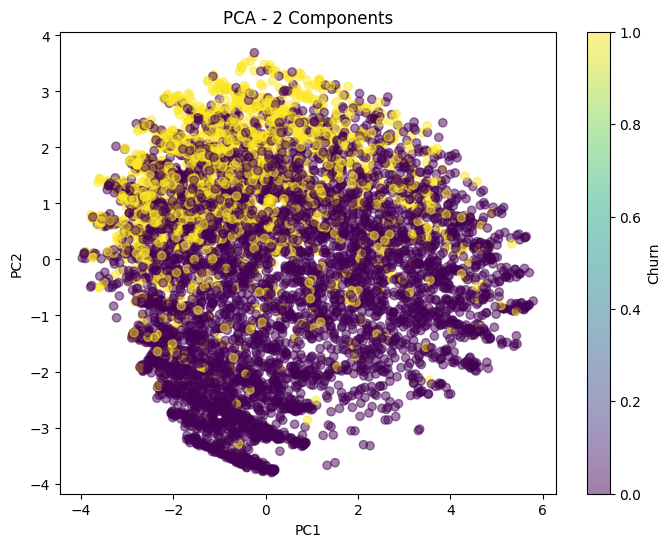

In [6]:
# 5. Visualizing Complexity (Dimensionality Reduction)
# Standardize data first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
prob_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(prob_pca[:,0], prob_pca[:,1], c=y, cmap='viridis', alpha=0.5)
plt.title('PCA - 2 Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Churn')
plt.show()

## 6. Clustering

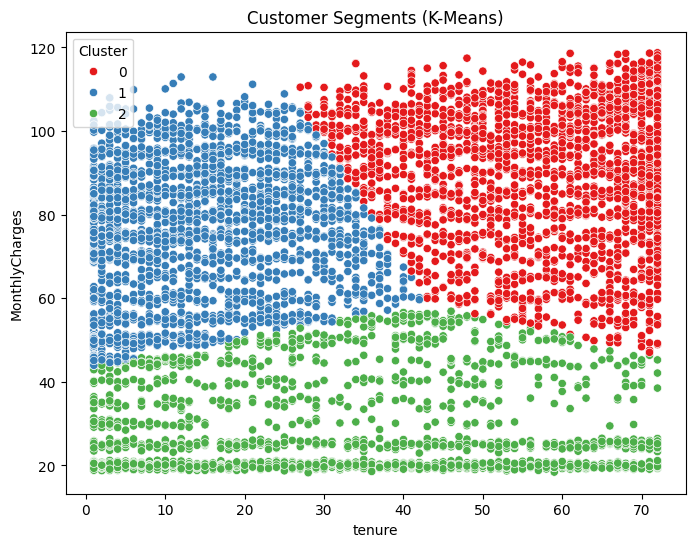

In [7]:
# 6. Customer Profiling (Clustering)
# Using KMeans to find customer segments based on Tenure and MonthlyCharges
X_cluster = df[['tenure', 'MonthlyCharges']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(8,6))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Cluster', data=df, palette='Set1')
plt.title('Customer Segments (K-Means)')
plt.show()

## 7. Classification (Predictive Modeling)

In [8]:
# 7. Future Prediction (Classification)
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7427149964463398
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1033
           1       0.52      0.51      0.51       374

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407



## 8. Model Enhancement (XGBoost)

In [9]:
# 8. Model Enhancement (Ensemble & Boosting)
# XGBoost Optimized for Accuracy (Target: 80%+)
xgb_model = xgb.XGBClassifier(
    use_label_encoder=False, 
    eval_metric='error',  # Optimize for accuracy
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1    # Default weight for accuracy
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7896233120113717
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## 9. Anomaly Detection

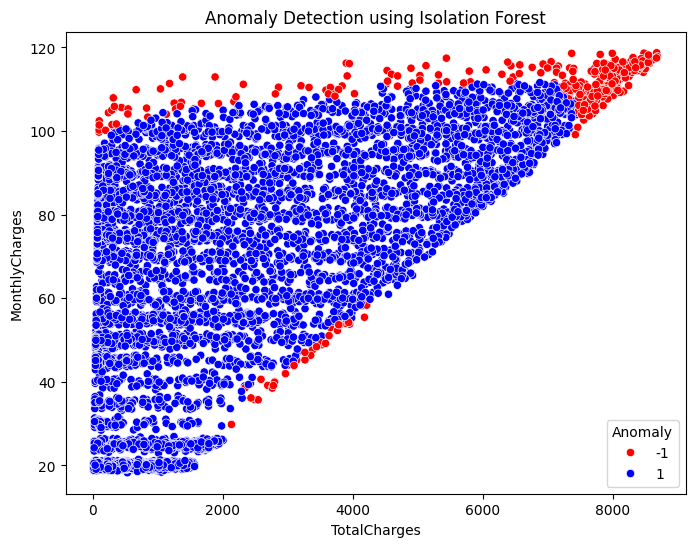

Number of Anomalies Detected: 352


In [10]:
# 9. Security & Quality Control (Anomaly Detection)
# Detect anomalies in 'TotalCharges' and 'MonthlyCharges'
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly'] = iso_forest.fit_predict(df[['TotalCharges', 'MonthlyCharges']])

# Anomaly = -1, Normal = 1
plt.figure(figsize=(8,6))
sns.scatterplot(x='TotalCharges', y='MonthlyCharges', hue='Anomaly', data=df, palette={1:'blue', -1:'red'})
plt.title('Anomaly Detection using Isolation Forest')
plt.show()

print("Number of Anomalies Detected:", len(df[df['Anomaly'] == -1]))

## 10. Web Backend Integration

In [11]:
%pip install flask flask-cors pyngrok

Note: you may need to restart the kernel to use updated packages.


In [12]:
# 10. Web Application Backend (Flask + Ngrok)
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
import threading

# Define the app
app = Flask(__name__)
CORS(app)

# We use the 'model' and 'scaler' variables that are already in memory 
# from the previous cells in this notebook (Step 7: Classification).
# Ensure you have run the training cells before starting the app!

@app.route('/')
def home():
    return "Churn Prediction API is Running in Colab!"

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        
        # Prepare input vector (simulated from raw inputs)
        # We need to match the feature structure used in training (X_scaled)
        # For this demo, to be safe, we will assume the simplest case:
        # We construct a DataFrame with the columns X had.
        
        # NOTE: In a real scenario, you must reproduce the EXACT preprocessing pipeline.
        # Here we re-use the 'scaler' and 'feature columns' from the notebook context.
        
        # Access global X from previous cell to get columns
        input_df = pd.DataFrame(columns=X.columns)
        input_df.loc[0] = 0
        
        # Map basics
        if 'tenure' in data: input_df['tenure'] = float(data['tenure'])
        if 'MonthlyCharges' in data: input_df['MonthlyCharges'] = float(data['MonthlyCharges'])
        if 'TotalCharges' in data: input_df['TotalCharges'] = float(data['TotalCharges'])
        
        # Feature Engineering (must match Step 4)
        input_df['AvgChargePerTenure'] = input_df['TotalCharges'] / (input_df['tenure'] + 0.01)
        
        # Scale
        input_scaled = scaler.transform(input_df)
        
        # Predict
        # Use the 'xgb_model' from Step 8 if available, else 'dt_model'
        active_model = xgb_model if 'xgb_model' in globals() else dt_model
        
        pred = active_model.predict(input_scaled)[0]
        prob = active_model.predict_proba(input_scaled)[0][1] if hasattr(active_model, 'predict_proba') else 0.0
        
        return jsonify({
            'churn_prediction': int(pred),
            'churn_probability': float(prob),
            'message': "Likely to Churn" if pred == 1 else "Loyal Customer"
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 400

# Setup Ngrok
# IMPORTANT: Put your Ngrok Authtoken here!
# Get it from: https://dashboard.ngrok.com/get-started/your-authtoken
# ngrok.set_auth_token("2qGVvVv8xaS472uAe3aVm_6hgzUE1fJcikUPQQdYZFg")

# public_url = ngrok.connect(5000).public_url
# print(f"Public URL: {public_url}")

# Run Flask in a separate thread
threading.Thread(target=app.run, kwargs={'port': 5000}).start()


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
